## 🎮 Video Game Sales Analysis & Business Insights

### 🎯 Business Objective
This project analyzes global video game sales data to uncover:
- Revenue trends across years
- Top-performing genres and platforms
- Regional market behavior
- Key factors influencing global sales

### 💼 Business Use Case
Gaming companies can use this analysis to:
- Identify profitable genres
- Target high-performing regions
- Optimize platform strategy
- Forecast future sales

### 📂 Dataset Information
- Source: Video Game Sales Dataset
- Time Period: Up to 2017
- Includes only games with sales > 100,000 copies
### ⚠️ Limitations
- Does not include low-selling or indie games
- Excludes modern trends (mobile, digital-only games)
- Represents successful games only

👉 Therefore, insights reflect **high-performing games**, not the entire market

## IMPORTING LIBRARIES

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## DATA MANIPULATING AND CLEANING

CREATING THE DATAFRAME

In [24]:
data = pd.read_csv('vgsales.csv')
df = pd.DataFrame(data)
df.head()

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


GENERATING INFORMATION OF THE DATAFRAME

In [25]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 16598 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16598 non-null  int64  
 1   Name          16598 non-null  str    
 2   Platform      16598 non-null  str    
 3   Year          16327 non-null  float64
 4   Genre         16598 non-null  str    
 5   Publisher     16540 non-null  str    
 6   NA_Sales      16598 non-null  float64
 7   EU_Sales      16598 non-null  float64
 8   JP_Sales      16598 non-null  float64
 9   Other_Sales   16598 non-null  float64
 10  Global_Sales  16598 non-null  float64
dtypes: float64(6), int64(1), str(4)
memory usage: 2.1 MB


FILLING THE NULL VALUES 

In [41]:
df.isnull().sum()
data = data.dropna(subset=['Year', 'Publisher'])
data['Year'] = data['Year'].astype(int)
print(f'Number of rows after dropping missing values: {len(data)}')

Number of rows after dropping missing values: 16291


SORTING COLUMNS

In [27]:
multi_sort = df.sort_values(by=['Year', 'Name'], ascending=[True, False])
print(f'{multi_sort.head(5)}\n')

      Rank             Name Platform    Year    Genre   Publisher  NA_Sales  \
544    545  Missile Command     2600  1980.0  Shooter       Atari      2.56   
1766  1768          Kaboom!     2600  1980.0     Misc  Activision      1.07   
4025  4027       Ice Hockey     2600  1980.0   Sports  Activision      0.46   
5366  5368          Freeway     2600  1980.0   Action  Activision      0.32   
1969  1971         Defender     2600  1980.0     Misc       Atari      0.99   

      EU_Sales  JP_Sales  Other_Sales  Global_Sales  
544       0.17       0.0         0.03          2.76  
1766      0.07       0.0         0.01          1.15  
4025      0.03       0.0         0.01          0.49  
5366      0.02       0.0         0.00          0.34  
1969      0.05       0.0         0.01          1.05  



## DATA ANALYSIS and VISUALIZATION

Games released per platform

Total number of platforms: 31



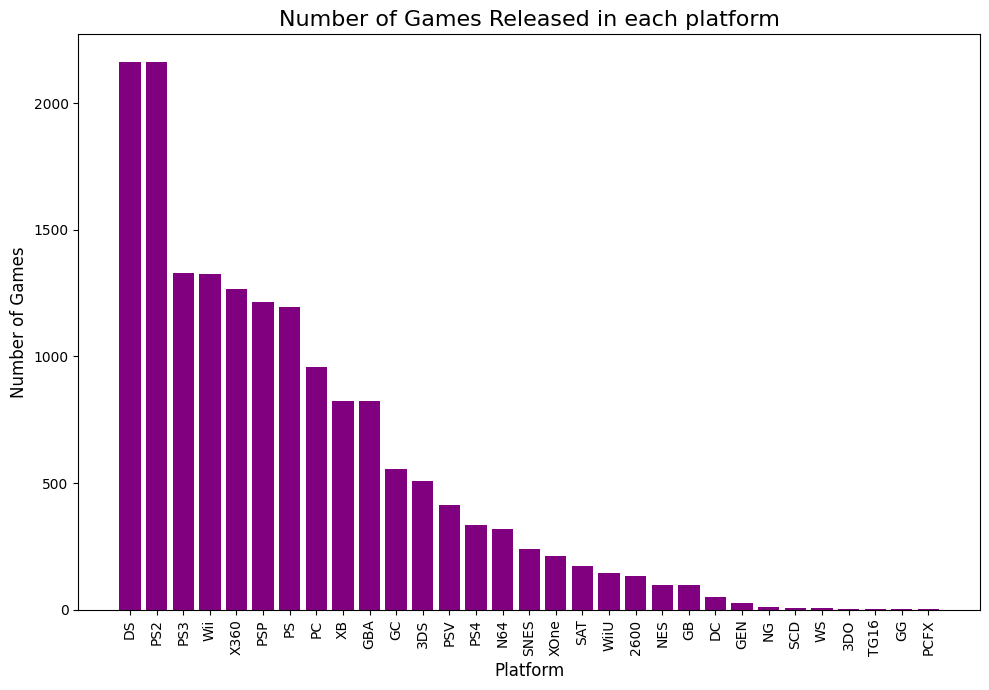

In [28]:
platform_count = df['Platform'].value_counts()
print(f'Total number of platforms: {len(platform_count)}\n')

platform_games = data['Platform'].value_counts()
plt.figure(figsize=(10, 7))
plt.bar(platform_games.index, platform_games.values, color='purple')
plt.xlabel('Platform', fontsize=12)
plt.ylabel('Number of Games', fontsize=12)
plt.title('Number of Games Released in each platform', fontsize=16)
plt.xticks(rotation=90)  
plt.tight_layout()
plt.show()

### 💡 Key Insights
- DS,PS2,PS3,Wii have the highest number of game releases.
- Platforms with more games tend to dominate market presence.
- However, higher quantity does not always mean higher revenue.

Games released per year

Total number of years: 39



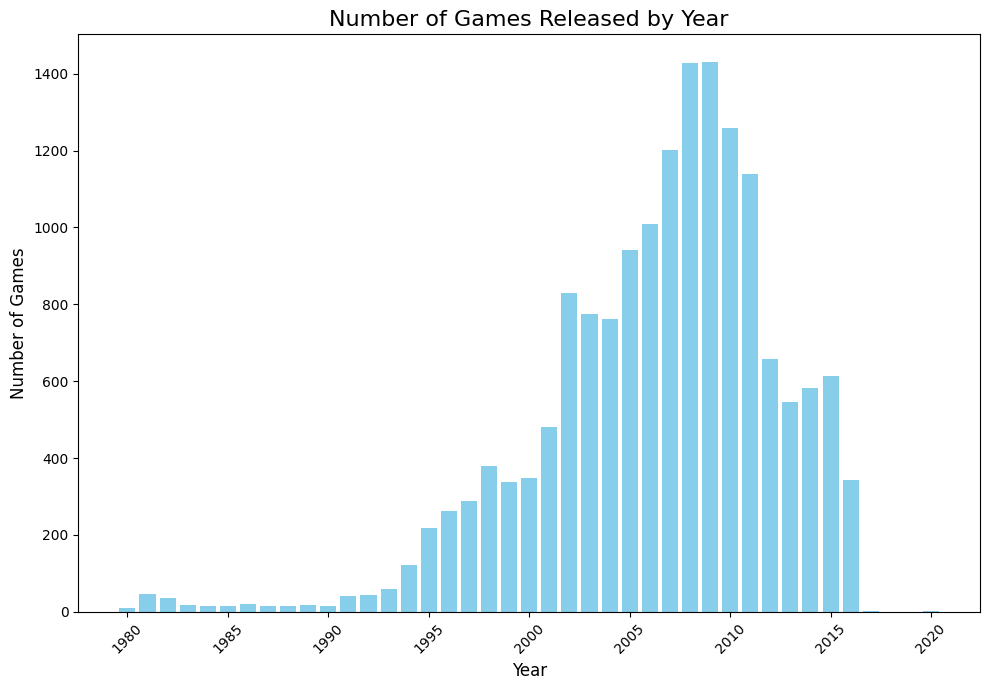

In [29]:
year_count = df['Year'].value_counts()
print(f'Total number of years: {len(year_count)}\n')

plt.figure(figsize=(10, 7))
plt.bar(year_count.index, year_count.values, color='skyblue')
plt.xlabel('Year',fontsize=12)
plt.ylabel('Number of Games',fontsize=12)
plt.title('Number of Games Released by Year',fontsize=16)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 💡 Key Insights
- Game releases increased steadily until around 2008–2010.
- A decline after 2012 may reflect industry changes or dataset limitations.

Genre wise game released

Total number of genres: 12



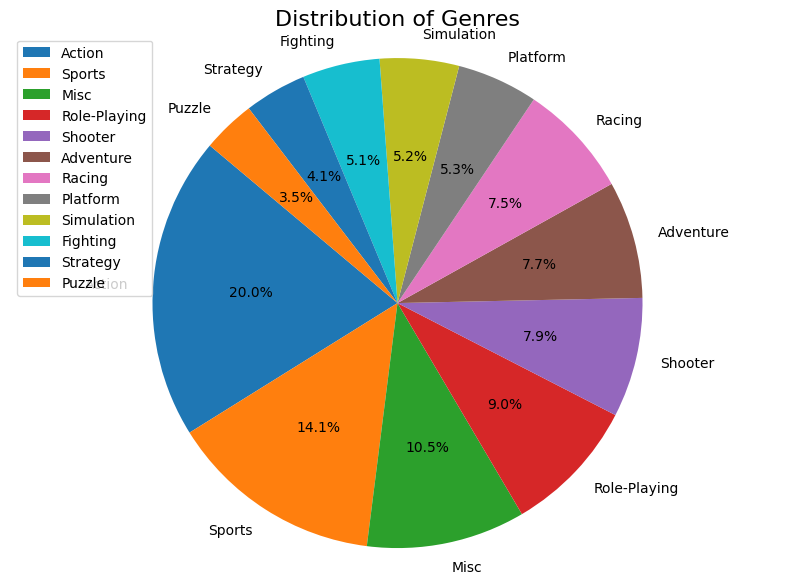

In [30]:
genre_count = df['Genre'].value_counts()
print(f'Total number of genres: {len(genre_count)}\n')

plt.figure(figsize=(10, 7))
plt.pie(genre_count,labels=genre_count.index, autopct='%1.1f%%', startangle=140)
plt.axis('equal')
plt.title('Distribution of Genres',fontsize=16)
plt.legend(genre_count.index, loc='upper left')
plt.show()

### 💡 Key Insights
- Action and Sports genres have the highest number of releases.
- These genres are consistently popular among developers and gamers.
- Market demand drives higher production in these categories.

Game publishers analysis

In [31]:
publisher_count = df['Publisher'].value_counts()
print(f'Total number of publishers: {len(publisher_count)}\n')
print(f'Publisher with Most games:{publisher_count.head(5)}\n')
print(f'Publisher with Least games:{publisher_count.tail(5)}')

Total number of publishers: 578

Publisher with Most games:Publisher
Electronic Arts                 1351
Activision                       975
Namco Bandai Games               932
Ubisoft                          921
Konami Digital Entertainment     832
Name: count, dtype: int64

Publisher with Least games:Publisher
Inti Creates          1
Takuyo                1
Interchannel-Holon    1
Rain Games            1
UIG Entertainment     1
Name: count, dtype: int64


TOTAL GLOBAL SALES(LINE PLOT)

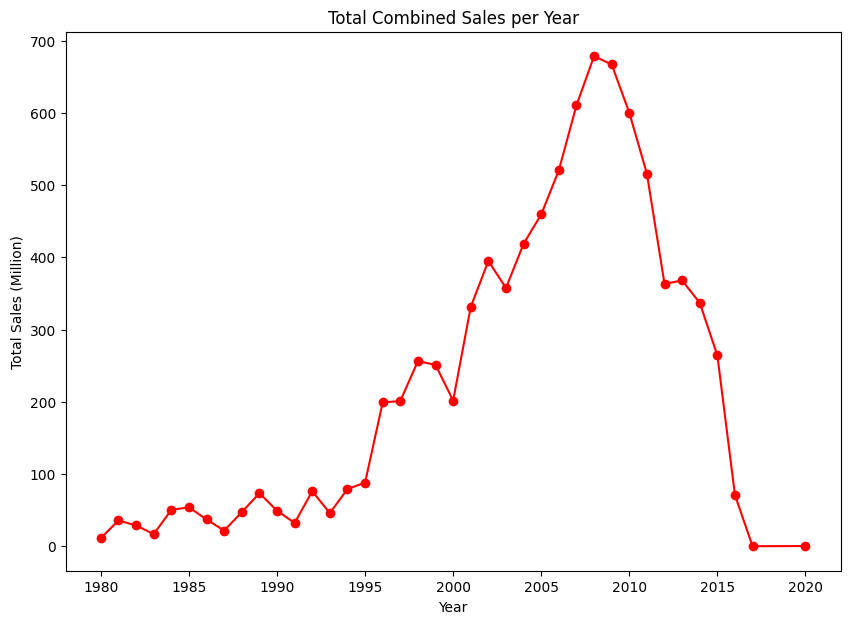

In [32]:
sales_yearly = data.groupby('Year')[['NA_Sales','EU_Sales','JP_Sales','Other_Sales']].sum()
sales_yearly['Total_Sales'] = sales_yearly.sum(axis=1)

plt.figure(figsize=(10, 7))
plt.plot(sales_yearly.index, sales_yearly['Total_Sales'], marker='o',color='red')
plt.xlabel('Year')
plt.ylabel('Total Sales (Million)')
plt.title('Total Combined Sales per Year')
plt.show()

### 💡 Key Insights
- The dataset represents a large-scale gaming market with significant revenue.
- Since only games with >100k sales are included, this reflects successful titles.

GLOBAL SALES BY GENRE(HORIZONTAL BAR PLOT)

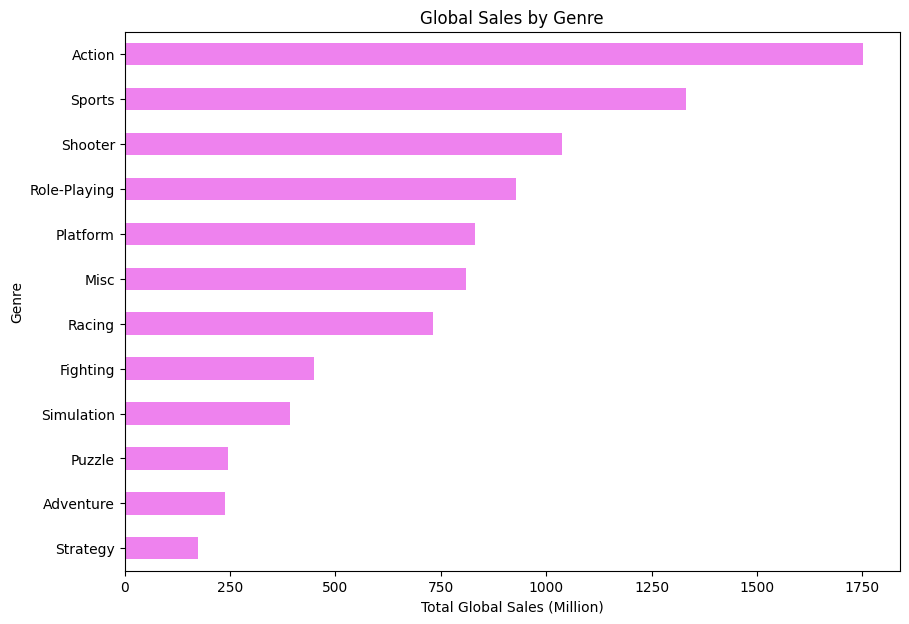

In [33]:
genre_sales = data.groupby('Genre')['Global_Sales'].sum().sort_values(ascending=True)

plt.figure(figsize=(10, 7))
genre_sales.plot(kind='barh', color='violet')

plt.xlabel('Total Global Sales (Million)')
plt.ylabel('Genre')
plt.title('Global Sales by Genre')
plt.show()

### 💡 Key Insights
- Action and Sports genres generate the highest revenue.
- Some genres may have fewer games but higher average sales.
- Genre selection is a key factor in profitability.

GLOBAL SALES BY PUBLISHER(pie chart)

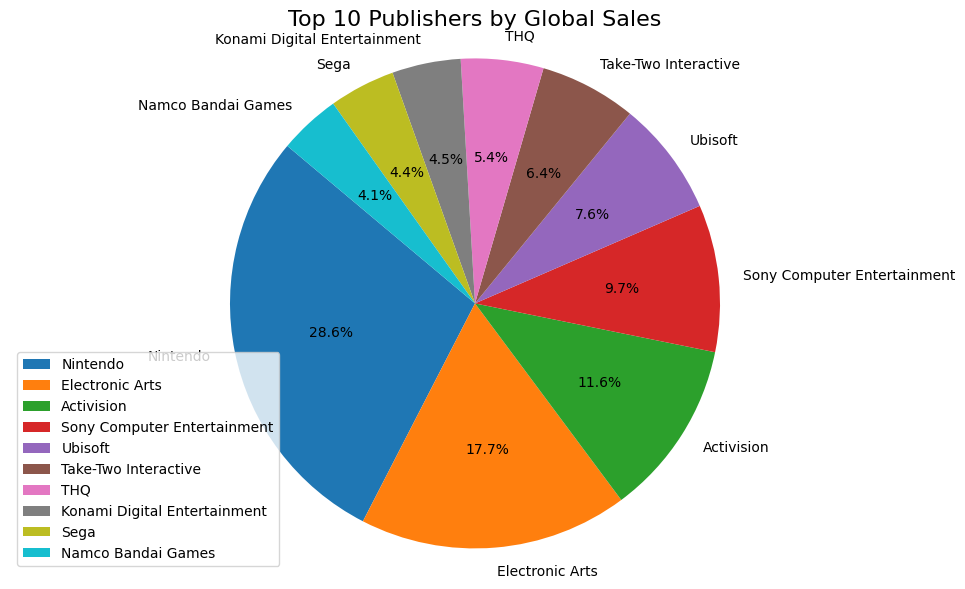

In [34]:

top_publishers = df.groupby('Publisher')['Global_Sales'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(12,7))
plt.pie(top_publishers, labels=top_publishers.index, autopct='%1.1f%%', startangle=140)
plt.axis('equal')
plt.title('Top 10 Publishers by Global Sales', fontsize=16)
plt.legend(top_publishers.index, loc='lower left')
plt.show()

### 💡 Key Insights
- Top publishers generate a large share of total revenue.
- Market dominance is concentrated among a few major companies.
- Successful publishers balance quantity and quality.

Platform wise Global sales

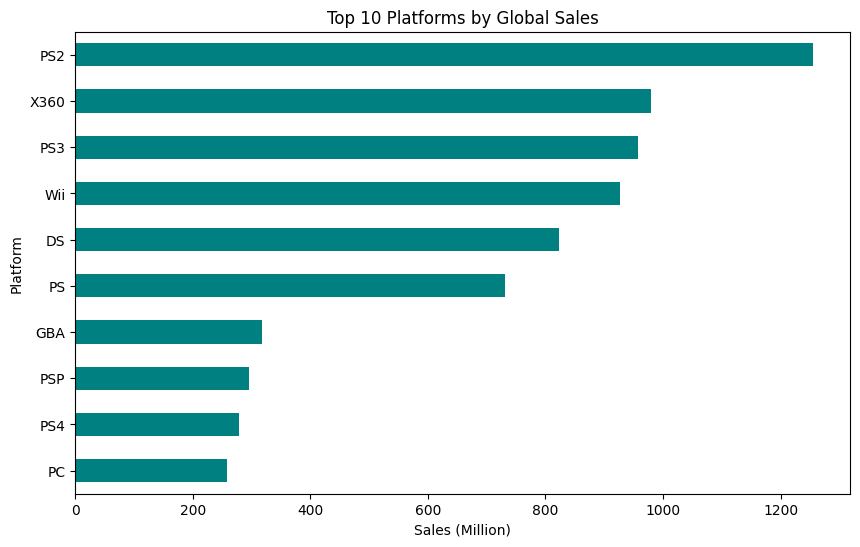

In [35]:
platform_sales = data.groupby('Platform')['Global_Sales'].sum().sort_values(ascending=False).head(10)
platform_sales = platform_sales.sort_values(ascending=True)

plt.figure(figsize=(10,6))
platform_sales.plot(kind='barh', color='teal')
plt.title('Top 10 Platforms by Global Sales')
plt.xlabel('Sales (Million)')
plt.ylabel('Platform')

plt.show()

### 💡 Key Insights
- Platforms like PS2, Xbox, and PS3 dominate global sales.
- Platform popularity directly impacts revenue generation.
- Timing and lifecycle of platforms are crucial for success.

## PIVOT TABLE

PIVOT TABLE: Sales by genre and region

In [37]:
pivot_genre_region = data.pivot_table(
    values=['NA_Sales','EU_Sales','JP_Sales','Other_Sales'],
    index='Genre',
    aggfunc='sum'
)
print(f'Pivot Table of Sales by Genre and Region:\n{pivot_genre_region}')

Pivot Table of Sales by Genre and Region:
              EU_Sales  JP_Sales  NA_Sales  Other_Sales
Genre                                                  
Action          525.00    159.95    877.83       187.38
Adventure        64.13     52.07    105.80        16.81
Fighting        101.32     87.35    223.59        36.68
Misc            215.98    107.76    410.24        75.32
Platform        201.63    130.77    447.05        51.59
Puzzle           50.78     57.31    123.78        12.55
Racing          238.39     56.69    359.42        77.27
Role-Playing    188.06    352.31    327.28        59.61
Shooter         313.27     38.28    582.60       102.69
Simulation      113.38     63.70    183.31        31.52
Sports          376.85    135.37    683.35       134.97
Strategy         45.34     49.46     68.70        11.36


PIVOT TABLE: Average Sales per Genre on Top Platforms

In [38]:
pivot_publisher = data.pivot_table(
    values='Global_Sales',
    index='Publisher',
    aggfunc='sum'
).sort_values(by='Global_Sales', ascending=False)
print(f'Pivot Table of Global Sales by Publisher:\n{pivot_publisher.head(10)}')

Pivot Table of Global Sales by Publisher:
                              Global_Sales
Publisher                                 
Nintendo                           1786.56
Electronic Arts                    1110.32
Activision                          727.46
Sony Computer Entertainment         607.50
Ubisoft                             474.72
Take-Two Interactive                399.54
THQ                                 340.77
Konami Digital Entertainment        283.64
Sega                                272.99
Namco Bandai Games                  254.09
